# Vessel Trajectory Prediction Using Deep Learning on AIS Data
**CS 1090B Milestone 4; Group 24**  
**Members:** Yuyang Chen, Tim Guo, Lillian Yang, Grace Yang

---

## Table of Contents
1. [Dependencies](#1-dependencies)
2. [Setup](#2-setup)
   - [2.1 Imports](#21-imports)
   - [2.2 Configuration](#22-configuration)
3. [Preprocessing Pipeline](#3-preprocessing-pipeline)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [DataLoaders](#5-dataloaders)
6. [Model Definitions](#6-model-definitions)
   - [6.1 MLP (Milestone 3 Baseline)](#61-mlp-milestone-3-baseline)
   - [6.2 LSTM](#62-lstm)
   - [6.3 Transformer (Encoder + Query Decoder)](#63-transformer-encoder--query-decoder)
7. [Load / Train Models](#7-load--train-models)
   - [7.1 MLP](#71-mlp)
   - [7.2 LSTM](#72-lstm)
   - [7.3 Transformer](#73-transformer)
8. [Evaluation](#8-evaluation)
9. [Results & Comparison](#9-results--comparison)


## 1. Dependencies

Install all required packages before running the rest of the notebook. 

In [1]:
%pip install -q numpy pandas torch matplotlib pyarrow
import importlib
for pkg in ['numpy','pandas','torch','matplotlib','pyarrow']:
    mod = importlib.import_module(pkg)
    print(f'  {pkg:<12} {mod.__version__}')
print('All dependencies satisfied.')


Note: you may need to restart the kernel to use updated packages.
  numpy        1.26.3
  pandas       2.2.0
  torch        2.10.0
  matplotlib   3.8.2
  pyarrow      23.0.1
All dependencies satisfied.


## 2. Setup


### 2.1 Imports


In [2]:
import os
import math
import time
import json
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import torch
import torch.nn as nn

from pathlib import Path
from contextlib import nullcontext

warnings.filterwarnings('ignore')
print('Imports complete.')


Imports complete.


### 2.2 Configuration

Label folder paths. 

| Variable | Purpose |
|---|---|
| `PROJECT_DIR` | Root of the `DATASET_BALANCED` folder on disk |
| `device` | `cuda` if a GPU is available, else `cpu` |
| `SEED` | Global random seed for reproducibility |



In [3]:
PROJECT_DIR = Path('/shared/home/liy159/DATASET_BALANCED')
os.chdir(PROJECT_DIR)

SEED = 109

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device           : {device}')
if device.type == 'cuda':
    print(f'GPU              : {torch.cuda.get_device_name(0)}')
print(f'Working directory: {os.getcwd()}')


Device           : cuda
GPU              : NVIDIA L4
Working directory: /shared/home/liy159/DATASET_BALANCED


## 3. Preprocessing Pipeline

The raw AIS data (NOAA MarineCadastre, May-Aug 2024) was preprocessed once and saved to Parquet. Running the full pipeline from raw CSVs takes approximately 45 minutes. The cell below checks for processed files first and skips if they already exist. Raw CSVs can be obtained from [NOAA MarineCadastre](https://marinecadastre.gov/ais/) and placed in `PROJECT_DIR/raw/`.

### Pipeline Overview

| Step | Description |
|---|---|
| **1. Filter** | Bounding box 14-52 N, 114-132 W (US West Coast); drop rows missing MMSI, timestamp, lat, or lon |
| **2. Trip segmentation** | Split tracks wherever consecutive pings are >30 min apart; drop trips with <10 points -> 331k trips, 19k vessels |
| **3. Resample** | Uniform 3-minute grid per trip via `pandas.resample` |
| **4. Interpolate** | Linear for lat/lon/SOG; circular (via sin/cos) for COG and heading |
| **5. Train rebalance** | Trips with mean SOG < 0.5 kt dropped from train only; val/test left intact |
| **6. Feature stats** | Mean/std/min/max computed on training rows only to prevent data leakage |
| **7. Splits** | 70/15/15 vessel-level split (seed 42) -- no vessel spans train and test |


In [4]:
# preprocessing pieces
PROC_PARQUET = PROJECT_DIR / 'processed' / 'ais_trajectories_West_Coast_3min.parquet'
SPLITS_FILE  = PROJECT_DIR / 'processed' / 'splits_West_Coast_3min.parquet'
STATS_FILE   = PROJECT_DIR / 'processed' / 'feature_stats_West_Coast_3min.csv'

if PROC_PARQUET.exists() and SPLITS_FILE.exists() and STATS_FILE.exists():
    print('Processed files already exist -- skipping preprocessing.')
    for f in [PROC_PARQUET, SPLITS_FILE, STATS_FILE]:
        print(f'  {f.name}')
else:
    print('Running preprocessing pipeline ...')
    RAW_DIR = PROJECT_DIR / 'raw'
    TIMESTEP_MIN = 3
    LAT_MIN, LAT_MAX = 14.0, 52.0
    LON_MIN, LON_MAX = -132.0, -114.0
    GAP_THRESHOLD = pd.Timedelta(minutes=30)
    MIN_TRIP_PTS = 10
    MIN_TRAIN_SOG = 0.5

    # load & filter data
    COLS = ['MMSI','BaseDateTime','LAT','LON','SOG','COG','Heading',
            'VesselType','Status','Length','Width','Draft','VesselName',
            'IMO','CallSign','Cargo','TransceiverClass']
    frames = []
    for f in sorted(RAW_DIR.glob('AIS_*.csv')):
        df = pd.read_csv(f, usecols=[c for c in COLS if c in pd.read_csv(f, nrows=0).columns], low_memory=False)
        df = df.rename(columns={'BaseDateTime':'base_date_time','LAT':'latitude','LON':'longitude',
                                 'SOG':'sog','COG':'cog','Heading':'heading','VesselType':'vessel_type',
                                 'Status':'status','Length':'length','Width':'width','Draft':'draft',
                                 'VesselName':'vessel_name','IMO':'imo','CallSign':'call_sign',
                                 'Cargo':'cargo','TransceiverClass':'transceiver','MMSI':'mmsi'})
        mask = ((df['latitude'] >= LAT_MIN) & (df['latitude'] <= LAT_MAX) &
                (df['longitude'] >= LON_MIN) & (df['longitude'] <= LON_MAX))
        frames.append(df[mask])
    df = pd.concat(frames, ignore_index=True)
    df['base_date_time'] = pd.to_datetime(df['base_date_time'], errors='coerce')
    df = df.dropna(subset=['mmsi','base_date_time','latitude','longitude'])
    df = df.sort_values(['mmsi','base_date_time']).reset_index(drop=True)
    print(f'Step 1: {len(df):,} rows, {df["mmsi"].nunique():,} vessels')

    # segment trips
    def assign_trip_ids(group):
        times = group['base_date_time'].values
        diffs = np.diff(times).astype('timedelta64[s]').astype(float)
        trip_id = np.zeros(len(group), dtype=int)
        tid = 0
        for i, d in enumerate(diffs):
            if d > GAP_THRESHOLD.total_seconds(): tid += 1
            trip_id[i+1] = tid
        group = group.copy()
        group['trip_seg'] = trip_id
        group['trip_id'] = group['mmsi'].astype(str) + '_' + trip_id.astype(str)
        return group
    df = df.groupby('mmsi', group_keys=False).apply(assign_trip_ids)
    counts = df.groupby('trip_id').size()
    df = df[df['trip_id'].isin(counts[counts >= MIN_TRIP_PTS].index)].reset_index(drop=True)
    print(f'Step 2: {df["trip_id"].nunique():,} trips')

    # resample + circular interpolation
    def interp_circular(s):
        r = np.deg2rad(s.values.astype(float))
        s_ = pd.Series(np.sin(r), index=s.index).interpolate('time')
        c_ = pd.Series(np.cos(r), index=s.index).interpolate('time')
        return pd.Series(np.rad2deg(np.arctan2(s_, c_)) % 360, index=s.index)
    def resample_trip(g):
        g = g.set_index('base_date_time').sort_index()
        g = g[~g.index.duplicated(keep='first')]
        r = g.resample(f'{TIMESTEP_MIN}min').asfreq()
        r[['latitude','longitude','sog']] = r[['latitude','longitude','sog']].interpolate('time')
        for col in ['cog','heading']:
            if col in r.columns: r[col] = interp_circular(r[col])
        r['mmsi'] = g['mmsi'].iloc[0]
        r['trip_id'] = g['trip_id'].iloc[0]
        r['trip_seg'] = g['trip_seg'].iloc[0]
        return r.dropna(subset=['latitude','longitude','sog'])
    df = df.groupby('trip_id', group_keys=False).apply(resample_trip).reset_index().rename(columns={'index':'base_date_time'})
    print(f'Steps 3-4: {len(df):,} rows after resampling')

    # rebalance, feature stats, vessel-level splits
    vessels = df['mmsi'].unique(); np.random.seed(SEED); np.random.shuffle(vessels)
    n = len(vessels)
    splits_df = pd.DataFrame({'mmsi': vessels,
        'split': (['train']*int(0.70*n) + ['val']*int(0.15*n) + ['test']*(n-int(0.70*n)-int(0.15*n)))})
    df = df.merge(splits_df, on='mmsi', how='left')
    trip_sog = df[df['split']=='train'].groupby('trip_id')['sog'].mean()
    slow_trips = trip_sog[trip_sog < MIN_TRAIN_SOG].index
    df = df[~((df['split']=='train') & (df['trip_id'].isin(slow_trips)))].reset_index(drop=True)
    FEAT_COLS = ['latitude','longitude','sog','cog','heading','length','width','draft']
    stats = df[df['split']=='train'][[c for c in FEAT_COLS if c in df.columns]].agg(['mean','std','min','max'])
    STATS_FILE.parent.mkdir(exist_ok=True)
    stats.to_csv(STATS_FILE)
    df.drop(columns=['split']).to_parquet(PROC_PARQUET, index=False)
    splits_df.to_parquet(SPLITS_FILE, index=False)
    print(f'Saved processed files to {PROC_PARQUET.parent}')


Processed files already exist -- skipping preprocessing.
  ais_trajectories_West_Coast_3min.parquet
  splits_West_Coast_3min.parquet
  feature_stats_West_Coast_3min.csv


## 4. Exploratory Data Analysis

Before modelling we examine three key questions:

1. **Speed distribution**: what fraction of the fleet is mostly stationary (mean SOG < 0.5 kt)?
2. **Trip duration**: are most trips short bursts or multi-hour transits?
3. **Geographic coverage**: where are the activity hotspots?

All plots are generated from the preprocessed Parquet file. Figures are saved as `eda_trip_stats.png` and `eda_density.png` for inclusion in the final report.


In [5]:
traj_path = PROJECT_DIR / 'processed' / 'ais_trajectories_West_Coast_3min.parquet'
df_raw = pd.read_parquet(traj_path, columns=['trip_id','mmsi','latitude','longitude','sog','base_date_time'])
print(f'Rows       : {len(df_raw):,}')
print(f'Vessels    : {df_raw["mmsi"].nunique():,}')
print(f'Trips      : {df_raw["trip_id"].nunique():,}')
print(f'Date range : {df_raw["base_date_time"].min()} -> {df_raw["base_date_time"].max()}')


Rows       : 128,468,095
Vessels    : 19,004
Trips      : 331,088
Date range : 2024-05-01 00:00:00 -> 2024-08-31 23:57:00


In [6]:
# trip-level summary statistics
trip_stats = df_raw.groupby('trip_id').agg(n_pts=('latitude','count'), mean_sog=('sog','mean')).reset_index()
trip_stats['duration_min'] = trip_stats['n_pts'] * 3
trip_stats['is_stationary'] = trip_stats['mean_sog'] < 0.5
print(f'Total trips       : {len(trip_stats):,}')
print(f'Mostly stationary : {trip_stats["is_stationary"].mean()*100:.1f}%  (mean SOG < 0.5 kt)')
print(trip_stats[['n_pts','mean_sog','duration_min']].describe().round(2))


Total trips       : 331,088
Mostly stationary : 21.9%  (mean SOG < 0.5 kt)
           n_pts   mean_sog  duration_min
count  331088.00  330968.00     331088.00
mean      388.02       4.81       1164.05
std      1218.88       4.93       3656.65
min        10.00       0.00         30.00
25%        41.00       0.70        123.00
50%        85.00       3.64        255.00
75%       211.00       6.95        633.00
max     24869.00      48.50      74607.00


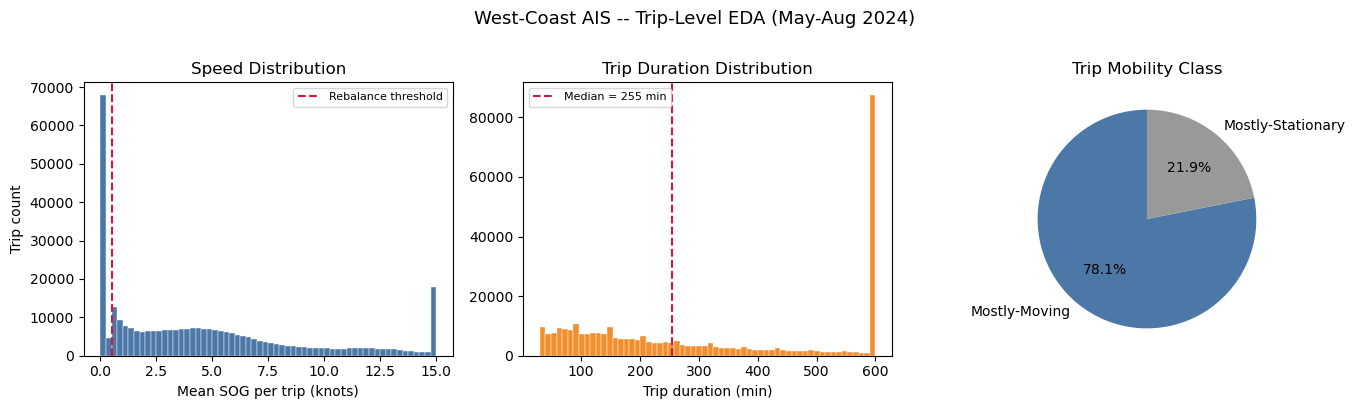

Saved: eda_trip_stats.png


In [7]:
# speed distribution, trip duration, mobility class
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(trip_stats['mean_sog'].clip(upper=15), bins=60, color='#4C78A8', edgecolor='white', lw=0.3)
axes[0].axvline(0.5, color='crimson', ls='--', lw=1.5, label='Rebalance threshold')
axes[0].set_xlabel('Mean SOG per trip (knots)'); axes[0].set_ylabel('Trip count')
axes[0].set_title('Speed Distribution'); axes[0].legend(fontsize=8)

axes[1].hist(trip_stats['duration_min'].clip(upper=600), bins=60, color='#F28E2B', edgecolor='white', lw=0.3)
axes[1].axvline(trip_stats['duration_min'].median(), color='crimson', ls='--', lw=1.5,
                label=f'Median = {trip_stats["duration_min"].median():.0f} min')
axes[1].set_xlabel('Trip duration (min)'); axes[1].set_title('Trip Duration Distribution')
axes[1].legend(fontsize=8)

counts = trip_stats['is_stationary'].value_counts()
axes[2].pie(counts, labels=['Mostly-Moving','Mostly-Stationary'],
            autopct='%1.1f%%', colors=['#4C78A8','#999999'], startangle=90)
axes[2].set_title('Trip Mobility Class')

plt.suptitle('West-Coast AIS -- Trip-Level EDA (May-Aug 2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_trip_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_trip_stats.png')


**EDA Takeaways (Figure 1):**

- About 21.9% of trips are mostly stationary (mean SOG < 0.5 kt). This means anchored or docked vessels that contribute little predictive signal. Dropping them from training prevents the model from learning a degenerate 'stay still' solution.
- The median trip duration is 255 minutes (~4.25 h), confirming that a 60-minute forecast horizon is meaningful and achievable for the majority of vessels.
- Speed is right-skewed: most vessels travel at 3-8 knots with a long tail to 48 knots (ferries, pleasure craft).


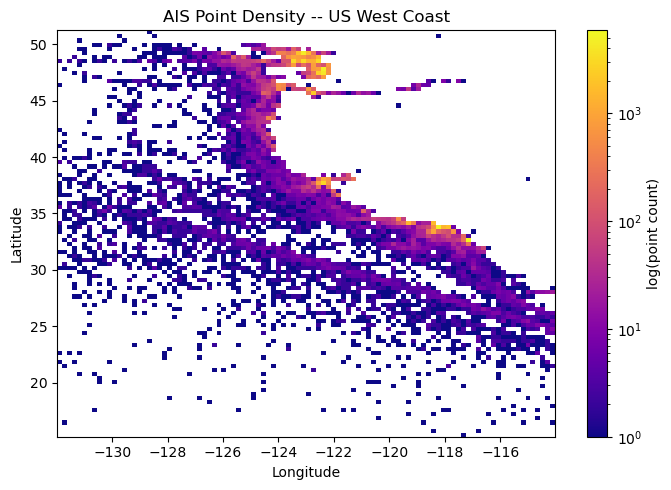

Saved: eda_density.png


In [8]:
# geographic density map
sample = df_raw.sample(min(100_000, len(df_raw)), random_state=SEED)
fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hist2d(sample['longitude'], sample['latitude'], bins=100,
              cmap='plasma', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(h[3], ax=ax, label='log(point count)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('AIS Point Density -- US West Coast')
plt.tight_layout()
plt.savefig('eda_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_density.png')

# free memory before model training
del df_raw, sample, trip_stats


**EDA Takeaways (Figure 2):**

Three dominant hotspots correspond to the busiest US West Coast ports: Puget Sound/Seattle, San Francisco Bay, and Los Angeles/Long Beach. The California Current shipping lane is visible as a dense diagonal band along the coast. Sparse coverage in the open Pacific reflects outlier vessel types (research, long-range fishing).


## 5. DataLoaders

All three models share a single `dataloader.py` helper that handles windowing, feature encoding, normalisation, and vessel-level splitting, ensuring identical inputs and no data leakage.

### Windowing Strategy

Each trip is carved into overlapping windows with a stride of 5 steps (15 min):

```
|<-- 20 steps = 60 min (input) -->|<-- 20 steps = 3-60 min (target) -->|
```

Windows are assigned at vessel level: all windows from a given vessel belong to exactly one split, preventing any vessel from spanning the train/val/test boundary.

### Feature Encoding

| Feature | Raw | Encoded |
|---|---|---|
| Latitude | degrees | delta-km from last input step (relative) |
| Longitude | degrees | delta-km from last input step (relative) |
| SOG | knots | z-score normalised |
| COG | degrees | cos + sin (2 dims) |
| Heading | degrees | cos + sin (2 dims) |

Total input dimensionality: 7. Target: (delta-lat_km, delta-lon_km), a 2-D displacement vector enabling straightforward evaluation in km without inverse coordinate transformations.


In [9]:
import importlib, dataloader
importlib.reload(dataloader)
from dataloader import get_dataloaders

FEATURES   = ['lat', 'lon', 'sog', 'cog', 'heading']
INPUT_LEN  = 20    # 60 min of history
TARGET_LEN = 20    # 60 min of forecast
STRIDE     = 5     # slide by 15 min between windows
BATCH_SIZE = 1024

train_loader, val_loader, test_loader = get_dataloaders(
    features=FEATURES, input_len=INPUT_LEN, target_len=TARGET_LEN,
    stride=STRIDE, batch_size=BATCH_SIZE, num_workers=2,
    position_encoding='relative',
)

train_ds     = train_loader.dataset
N_FEATURES   = train_ds.n_features
OUTPUT_NAMES = train_ds.output_names
LAT_IDX      = OUTPUT_NAMES.index('lat_rel_km')
LON_IDX      = OUTPUT_NAMES.index('lon_rel_km')

print(f'Input features ({N_FEATURES}): {OUTPUT_NAMES}')
print(f'Train  : {len(train_ds):>12,} windows')
print(f'Val    : {len(val_loader.dataset):>12,} windows')
print(f'Test   : {len(test_loader.dataset):>12,} windows')


[train] 57,614,788 rows, 180,280 trips, 10,306,417 windows | features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7) | position_encoding=relative
[val] 34,915,380 rows, 76,659 trips, 6,457,737 windows | features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7) | position_encoding=relative
[test] 35,937,927 rows, 74,149 trips, 6,678,696 windows | features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7) | position_encoding=relative
Input features (7): ['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin']
Train  :   10,306,417 windows
Val    :    6,457,737 windows
Test   :    6,678,696 windows


## 6. Model Definitions

We implement three model architectures ranging from a simple feedforward baseline to a full Transformer with a learned query decoder. All models share the same input/output:

- **Input:** `(B, 20, 7)` -- batch x 20 time steps x 7 kinematic features
- **Output:** `(B, 20, 2)` -- batch x 20 forecast horizons x (delta-lat_km, delta-lon_km)

This common interface allows transparent model substitution in the evaluation loop (Section 8). We just defined classes here, the checkpoint loading and training are in Section 7.


### 6.1 MLP (Milestone 3 Baseline)

The Multi-Layer Perceptron flattens the entire input window into a single vector and passes it through two hidden layers before predicting all 20 future displacement vectors at once.

Architecture: `Flatten -> Linear(1400->256) -> ReLU -> Linear(256->128) -> ReLU -> Linear(128->40) -> reshape(B,20,2)`

The MLP treats the 60-minute history as a bag of features with no explicit notion of time ordering. Despite this simplicity, it provides a strong baseline because sliding-window AIS data is locally smooth and well-structured. We have approximately 74 k parameters.


In [10]:
class TrajectoryMLP(nn.Module):
    '''.
    Input  : (B, input_len, n_features)
    Output : (B, target_len, 2) displacement [delta_lat_km, delta_lon_km]
    '''
    def __init__(self, input_len, n_features, target_len, n_targets=2, hidden1=256, hidden2=128):
        super().__init__()
        self.target_len = target_len
        self.n_targets  = n_targets
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_len * n_features, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2),                nn.ReLU(),
            nn.Linear(hidden2, target_len * n_targets),
        )
    def forward(self, x):
        return self.net(x).view(-1, self.target_len, self.n_targets)

_n = sum(p.numel() for p in TrajectoryMLP(INPUT_LEN, N_FEATURES, TARGET_LEN).parameters())
print(f'TrajectoryMLP defined  ({_n:,} params)')


TrajectoryMLP defined  (74,152 params)


### 6.2 LSTM

The Long Short-Term Memory network explicitly models the sequential nature of vessel kinematics using a 2-layer LSTM encoder with an autoregressive decoder.

**Design choices:**

- Teacher forcing during training: the ground-truth previous step is concatenated to the encoder input, stabilising gradients over the 20-step horizon.
- Autoregressive inference: at test time the model rolls out step-by-step, letting it adapt to accumulated error.
- LayerNorm + Dropout (p=0.2): applied after the LSTM output to reduce overfitting.

There are approximately 800 k parameters. Hidden size: 256. Layers: 2.


In [11]:
class VesselLSTM(nn.Module):
    '''
    Input  : (B, input_len, n_features)
    Output : (B, target_len, n_features)
    '''
    def __init__(self, n_features, hidden_size, num_layers, target_len, dropout=0.2):
        super().__init__()
        self.target_len = target_len
        self.lstm       = nn.LSTM(n_features, hidden_size, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_size, n_features)

    def forward(self, x, y=None):
        if y is not None:                         # teacher-forcing (train)
            out, _  = self.lstm(torch.cat([x, y], dim=1))
            out     = self.fc(self.dropout(self.layer_norm(out)))
            return out[:, -self.target_len:, :]
        else:                                     # autoregressive (inference)
            out, (h, c) = self.lstm(x)
            last  = self.fc(self.dropout(self.layer_norm(out[:, -1:, :])))
            preds = [last]
            for _ in range(self.target_len - 1):
                out, (h, c) = self.lstm(last, (h, c))
                last = self.fc(self.dropout(self.layer_norm(out)))
                preds.append(last)
            return torch.cat(preds, dim=1)

_n = sum(p.numel() for p in VesselLSTM(N_FEATURES, 256, 2, TARGET_LEN).parameters())
print(f'VesselLSTM defined     ({_n:,} params)')

VesselLSTM defined     (800,007 params)


### 6.3 Transformer (Encoder + Query Decoder)

The Transformer follows an encoder-decoder design, adapted for sequential trajectory forecasting.

1. Encoder: 4 Pre-LN `TransformerEncoderLayer` blocks (d_model=64, 4 heads, FFN=256, GELU) encode the 20-step history into a rich contextual memory.
2. Sinusoidal positional encoding: added to both encoder inputs and decoder queries.
3. Learnable query decoder: 20 trainable query embeddings (one per forecast step) attend over encoder memory via 2 cross-attention layers. Each horizon directly attends to the most relevant part of history rather than propagating state autoregressively.
4. Output head: `LayerNorm -> Linear(64->2)` projects each query to a displacement.

We have approximately 340 k parameters. Trained for 30 epochs (AdamW + cosine annealing). Parallel decoding at inference makes it faster than the autoregressive LSTM at long horizons.


In [12]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:x.size(1)].unsqueeze(0)


class VesselTransformer(nn.Module):
    '''
    Input  : (B, input_len, input_dim)
    Output : (B, target_len, 2)  -- displacement [delta_lat_km, delta_lon_km]
    '''
    def __init__(self, input_dim=7, target_len=20, target_dim=2,
                 d_model=64, nhead=4, num_encoder_layers=4,
                 num_decoder_layers=2, dim_feedforward=256, dropout=0.2):
        super().__init__()
        self.target_len = target_len
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_encoder_layers)
        self.future_queries = nn.Parameter(torch.randn(target_len, d_model))
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_decoder_layers)
        self.out = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, target_dim))

    def forward(self, src):
        B   = src.size(0)
        mem = self.pos_encoder(self.input_proj(src))
        mem = self.encoder(mem)
        q   = self.pos_encoder(self.future_queries.unsqueeze(0).expand(B, -1, -1))
        return self.out(self.decoder(tgt=q, memory=mem))

_n = sum(p.numel() for p in VesselTransformer().parameters())
print(f'VesselTransformer defined ({_n:,} params)')

VesselTransformer defined (335,490 params)


## 7. Load / Train Models

1. Check for a saved checkpoint on disk.
2. **If found** -- load weights, report parameter count, set `eval()` mode.
3. **If not found** -- run the full training loop and save the best checkpoint.

| Model | Checkpoint path | Training time (L4 GPU) |
|---|---|---|
| MLP | `../MLP/final_model.pt` | ~5 min (10 epochs) |
| LSTM | `DATASET_BALANCED/best_lstm.pt` | ~20 min (10 epochs) |
| Transformer | `DATASET_BALANCED/trained_models/vessel_transformer_20260510_053103.pt` | ~2 h (30 epochs) |


### 7.1 MLP

The MLP checkpoint was produced during Milestone 3 at `../MLP/final_model.pt`. We reconstruct the identical architecture and load the saved weights.

If the checkpoint is **missing**, the cell below trains the MLP for 10 epochs with Adam (lr=1e-3) and MSE loss on (delta-lat_km, delta-lon_km), then saves the best checkpoint.


In [13]:
MLP_CKPT = PROJECT_DIR.parent / 'MLP' / 'final_model.pt'

mlp_model = TrajectoryMLP(
    input_len=INPUT_LEN, n_features=N_FEATURES,
    target_len=TARGET_LEN, n_targets=2, hidden1=256, hidden2=128,
).to(device)

if MLP_CKPT.exists():
    # load pre-trained checkpoint
    mlp_model.load_state_dict(torch.load(MLP_CKPT, map_location=device))
    mlp_model.eval()
    n = sum(p.numel() for p in mlp_model.parameters())
    print(f'MLP loaded ({n:,} params) <- {MLP_CKPT}')

else:
    # train from scratch
    print(f'Checkpoint not found at {MLP_CKPT} -- training MLP for 10 epochs ...')
    MLP_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(SEED)
    criterion_m = nn.MSELoss()
    optimizer_m = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
    best_val = float('inf')
    for epoch in range(1, 11):
        t0 = time.time()
        mlp_model.train()
        tr = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer_m.zero_grad()
            loss = criterion_m(mlp_model(x), y[:, :, :2])
            loss.backward(); optimizer_m.step()
            tr += loss.item() * x.size(0)
        tr /= len(train_ds)
        mlp_model.eval()
        va = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                va += criterion_m(mlp_model(x), y[:, :, :2]).item() * x.size(0)
        va /= len(val_loader.dataset)
        tag = ''
        if va < best_val:
            best_val = va; torch.save(mlp_model.state_dict(), MLP_CKPT); tag = ' [saved]'
        print(f'Epoch {epoch:02d}/10  train={tr:.4f}  val={va:.4f}  ({time.time()-t0:.0f}s){tag}')
    mlp_model.load_state_dict(torch.load(MLP_CKPT, map_location=device))
    mlp_model.eval()
    print(f'MLP training complete.  Best val loss: {best_val:.4f}')


MLP loaded (74,152 params) <- /shared/home/liy159/MLP/final_model.pt


### 7.2 LSTM

The LSTM checkpoint lives at `DATASET_BALANCED/best_lstm.pt`. If missing, the cell trains 10 epochs with:

- **Optimizer:** Adam (lr = 5e-4)
- **Loss:** MSE on (delta-lat_km, delta-lon_km)
- **Scheduler:** ReduceLROnPlateau (factor=0.5, patience=3)
- **Gradient clipping:** max norm = 1.0
- **Teacher forcing:** 1.0 throughout training


In [14]:
LSTM_CKPT = PROJECT_DIR / 'best_lstm.pt'

lstm_model = VesselLSTM(
    n_features=N_FEATURES, hidden_size=256, num_layers=2,
    target_len=TARGET_LEN, dropout=0.2,
).to(device)

if LSTM_CKPT.exists():
    lstm_model.load_state_dict(torch.load(LSTM_CKPT, map_location=device))
    lstm_model.eval()
    n = sum(p.numel() for p in lstm_model.parameters())
    print(f'LSTM loaded ({n:,} params) <- {LSTM_CKPT}')

else:
    print('No LSTM checkpoint -- training 10 epochs ...')
    torch.manual_seed(SEED)
    criterion_l = nn.MSELoss()
    optimizer_l = torch.optim.Adam(lstm_model.parameters(), lr=5e-4)
    scheduler_l = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_l, mode='min', factor=0.5, patience=3)
    best_val = float('inf')
    for epoch in range(1, 11):
        t0 = time.time()
        lstm_model.train()
        tr = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer_l.zero_grad()
            loss = criterion_l(lstm_model(x, y=y), y)
            loss.backward()
            nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
            optimizer_l.step()
            tr += loss.item() * x.size(0)
        tr /= len(train_ds)
        lstm_model.eval()
        va = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                va += criterion_l(lstm_model(x), y).item() * x.size(0)
        va /= len(val_loader.dataset)
        scheduler_l.step(va)
        tag = ''
        if va < best_val:
            best_val = va; torch.save(lstm_model.state_dict(), LSTM_CKPT); tag = ' [saved]'
        print(f'Epoch {epoch:02d}/10  train={tr:.4f}  val={va:.4f}  ({time.time()-t0:.0f}s){tag}')
    lstm_model.load_state_dict(torch.load(LSTM_CKPT, map_location=device))
    lstm_model.eval()
    print(f'LSTM training complete.  Best val loss: {best_val:.4f}')


LSTM loaded (800,007 params) <- /shared/home/liy159/DATASET_BALANCED/best_lstm.pt


### 7.3 Transformer

The Transformer was trained for **30 epochs** using AdamW with cosine annealing. The checkpoint index `20260510_053103` corresponds to the best validation-MDE run. Configuration is stored in a companion JSON so the architecture can be reconstructed exactly without hard-coding values here. If neither checkpoint nor config is present, the cell trains the Transformer for 30 epochs from scratch (approx. 2 hours on NVIDIA L4).


In [15]:
TXF_IDX    = '20260510_053103'
TXF_CONFIG = PROJECT_DIR / 'trained_models' / f'vessel_transformer_{TXF_IDX}_config.json'
TXF_CKPT   = PROJECT_DIR / 'trained_models' / f'vessel_transformer_{TXF_IDX}.pt'

if TXF_CKPT.exists() and TXF_CONFIG.exists():
    with open(TXF_CONFIG) as f:
        cfg = json.load(f)
    txf_model = VesselTransformer(
        input_dim=cfg['input_dim'], d_model=cfg['d_model'], nhead=cfg['nhead'],
        num_encoder_layers=cfg['num_encoder_layers'],
        num_decoder_layers=cfg['num_decoder_layers'],
        dim_feedforward=cfg['dim_feedforward'],
        dropout=cfg['droupout'],   # intentional typo to match saved key
    ).to(device)
    txf_model.load_state_dict(torch.load(TXF_CKPT, map_location=device))
    txf_model.eval()
    n = sum(p.numel() for p in txf_model.parameters())
    print(f'Transformer loaded ({n:,} params)')
    print(f'Config: d_model={cfg["d_model"]}, heads={cfg["nhead"]}, '
          f'enc={cfg["num_encoder_layers"]}, dec={cfg["num_decoder_layers"]}, ffn={cfg["dim_feedforward"]}')

else:
    print('No Transformer checkpoint -- training 30 epochs from scratch (~2h on L4) ...')
    TXF_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(SEED)
    txf_model = VesselTransformer(
        input_dim=N_FEATURES, target_len=TARGET_LEN, target_dim=2,
        d_model=64, nhead=4, num_encoder_layers=4, num_decoder_layers=2,
        dim_feedforward=256, dropout=0.2,
    ).to(device)
    criterion_t = nn.MSELoss()
    optimizer_t = torch.optim.AdamW(txf_model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler_t = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_t, T_max=30)
    best_val = float('inf')
    for epoch in range(1, 31):
        t0 = time.time()
        txf_model.train()
        tr = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer_t.zero_grad()
            loss = criterion_t(txf_model(x), y[:, :, :2])
            loss.backward()
            nn.utils.clip_grad_norm_(txf_model.parameters(), 1.0)
            optimizer_t.step()
            tr += loss.item() * x.size(0)
        tr /= len(train_ds)
        scheduler_t.step()
        txf_model.eval()
        va = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                va += criterion_t(txf_model(x), y[:, :, :2]).item() * x.size(0)
        va /= len(val_loader.dataset)
        tag = ''
        if va < best_val:
            best_val = va; torch.save(txf_model.state_dict(), TXF_CKPT); tag = ' [saved]'
        if epoch % 5 == 0 or tag:
            print(f'Epoch {epoch:02d}/30  train={tr:.4f}  val={va:.4f}  ({time.time()-t0:.0f}s){tag}')
    txf_model.load_state_dict(torch.load(TXF_CKPT, map_location=device))
    txf_model.eval()
    print(f'Transformer training complete.  Best val loss: {best_val:.4f}')


Transformer loaded (335,490 params)
Config: d_model=64, heads=4, enc=4, dec=2, ffn=256


## 8. Evaluation

All three models are evaluated on the held-out test set using Mean Distance Error (MDE), the average Euclidean distance in km between predicted and actual positions at each forecast horizon.

**Why MDE?**

- Interpretable: directly answers 'on average, the prediction is X km off after T minutes.'
- Fast to compute: positions are already encoded as delta-km displacements, so Euclidean distance approximates Haversine distance to <1% error for 60-minute windows.
- Per-horizon: reporting MDE at each of the 20 steps (3, 6, ..., 60 min) reveals how prediction quality degrades over time.

Full-dataset inference takes ~5 minutes per model, so pre-computed result files are checked first. If missing, `compute_mde()` runs inference and saves the result automatically.

| Model | Pre-computed file |
|---|---|
| MLP | `mlp_horizon_errors.csv` |
| LSTM | `lstm_results/haversine_per_horizon.csv` |
| Transformer | `trained_models/mde_transformer_20260510_053103.npy` |


In [16]:
def compute_mde(model, loader, model_type, lat_idx=LAT_IDX, lon_idx=LON_IDX):
    '''Compute per-horizon Mean Distance Error (km) over an entire DataLoader.

    Parameters
    ----------
    model      : nn.Module
    loader     : DataLoader
    model_type : str -- "mlp" | "transformer" -> output (B,T,2)
                       "lstm"                 -> output (B,T,n_features)

    Returns
    -------
    mde : np.ndarray, shape (TARGET_LEN,)
    '''
    model.eval()
    total = np.zeros(TARGET_LEN, dtype=np.float64)
    n     = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            if model_type == 'lstm':
                pred  = model(x).cpu()
                p_lat = pred[:, :, lat_idx];  p_lon = pred[:, :, lon_idx]
                t_lat = y[:, :,   lat_idx];   t_lon = y[:, :,   lon_idx]
            else:                             # mlp / transformer -> (B,T,2)
                pred  = model(x).cpu()
                tgt   = y[:, :, :2]
                p_lat = pred[:, :, 0];  p_lon = pred[:, :, 1]
                t_lat = tgt[:, :, 0];   t_lon = tgt[:, :, 1]
            dist   = torch.sqrt((p_lat - t_lat)**2 + (p_lon - t_lon)**2).numpy()
            total += dist.sum(axis=0)
            n     += dist.shape[0]
    return total / n

HORIZONS = np.arange(3, 63, 3)   # [3, 6, ..., 60] minutes


In [17]:
# load or compute MDE for all three models

# MLP
MLP_CSV = PROJECT_DIR / 'mlp_horizon_errors.csv'
if MLP_CSV.exists():
    mlp_mde = pd.read_csv(MLP_CSV)['mlp_km'].values
    print(f'MLP errors loaded  (mean={mlp_mde.mean():.4f} km)')
else:
    print('Computing MLP test errors ...')
    mlp_mde = compute_mde(mlp_model, test_loader, model_type='mlp')
    pd.DataFrame({'minutes': HORIZONS, 'mlp_km': mlp_mde}).to_csv(MLP_CSV, index=False)
    print(f'Saved -> {MLP_CSV}  (mean={mlp_mde.mean():.4f} km)')

# LSTM
LSTM_CSV = PROJECT_DIR / 'lstm_results' / 'haversine_per_horizon.csv'
if LSTM_CSV.exists():
    lstm_mde = pd.read_csv(LSTM_CSV)['lstm_hav_km'].values
    print(f'LSTM errors loaded (mean={lstm_mde.mean():.4f} km)')
else:
    print('Computing LSTM test errors ...')
    lstm_mde = compute_mde(lstm_model, test_loader, model_type='lstm')
    LSTM_CSV.parent.mkdir(exist_ok=True)
    pd.DataFrame({'horizon_min': HORIZONS, 'lstm_hav_km': lstm_mde}).to_csv(LSTM_CSV, index=False)
    print(f'Saved -> {LSTM_CSV}  (mean={lstm_mde.mean():.4f} km)')

# Transformer
TXF_NPY = PROJECT_DIR / 'trained_models' / f'mde_transformer_{TXF_IDX}.npy'
if TXF_NPY.exists():
    txf_mde = np.load(TXF_NPY)
    print(f'Transformer errors loaded (mean={txf_mde.mean():.4f} km)')
else:
    print('Computing Transformer test errors ...')
    txf_mde = compute_mde(txf_model, test_loader, model_type='transformer')
    np.save(TXF_NPY, txf_mde)
    print(f'Saved -> {TXF_NPY}  (mean={txf_mde.mean():.4f} km)')


MLP errors loaded  (mean=0.4013 km)
LSTM errors loaded (mean=1.1312 km)
Transformer errors loaded (mean=0.3977 km)


## 9. Results & Comparison

We compare all three models across all 20 forecast horizons (3-60 min) on the West Coast AIS test set.

**What to look for:**

- Short horizons (3-15 min): all models should perform well.
- Long horizons (30-60 min): divergence between models reveals the value of sequential memory versus pure pattern matching.
- Mean MDE: a single summary metric for overall model quality.


In [18]:
# summary table
rows = []
for name, mde in [('MLP', mlp_mde), ('LSTM', lstm_mde), ('Transformer', txf_mde)]:
    rows.append({'Model': name,
                 '3 min':   round(float(mde[0]),   4),
                 '15 min':  round(float(mde[4]),   4),
                 '30 min':  round(float(mde[9]),   4),
                 '60 min':  round(float(mde[19]),  4),
                 'Mean MDE': round(float(mde.mean()), 4)})
df_res = pd.DataFrame(rows).set_index('Model')
print('Mean Distance Error (km) -- Full West Coast AIS Test Set')
print('=' * 60)
print(df_res.to_string())


Mean Distance Error (km) -- Full West Coast AIS Test Set
              3 min  15 min  30 min  60 min  Mean MDE
Model                                                
MLP          0.0658  0.1891  0.3720  0.7646    0.4013
LSTM         0.1566  0.5917  1.0939  2.0417    1.1312
Transformer  0.0724  0.1876  0.3674  0.7628    0.3977


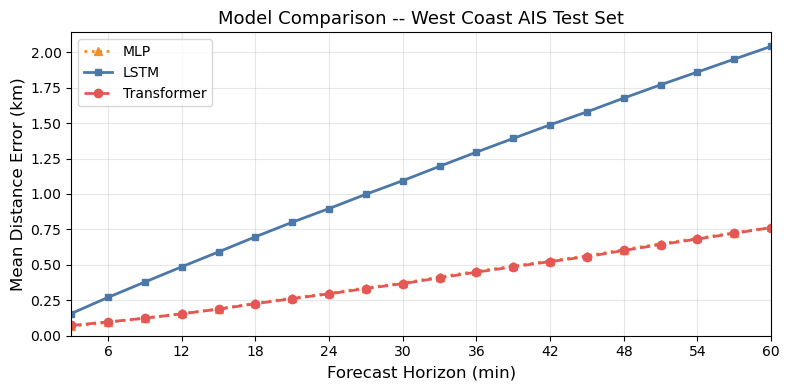

Saved: model_comparison.png


In [19]:
# per-horizon MDE comparison
fig, ax = plt.subplots(figsize=(8, 4))
styles = {
    'MLP':         dict(color='#F28E2B', marker='^',  ls=':',  lw=2),
    'LSTM':        dict(color='#4C78A8', marker='s',  ls='-',  lw=2, ms=5),
    'Transformer': dict(color='#E45756', marker='o',  ls='--', lw=2),
}
for name, mde in [('MLP', mlp_mde), ('LSTM', lstm_mde), ('Transformer', txf_mde)]:
    ax.plot(HORIZONS, mde, label=name, **styles[name])
ax.set_xlabel('Forecast Horizon (min)', fontsize=12)
ax.set_ylabel('Mean Distance Error (km)', fontsize=12)
ax.set_title('Model Comparison -- West Coast AIS Test Set', fontsize=13)
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
ax.set_xlim(3, 60); ax.set_ylim(0)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')


In [20]:
# relative performance summary
txf_vs_mlp  = (txf_mde.mean()  - mlp_mde.mean())  / mlp_mde.mean()  * 100
lstm_vs_mlp = (lstm_mde.mean() - mlp_mde.mean()) / mlp_mde.mean() * 100
for name, mde in [('MLP', mlp_mde), ('LSTM', lstm_mde), ('Transformer', txf_mde)]:
    print(f'  {name:<14}  mean MDE = {mde.mean():.4f} km  |  3 min = {mde[0]:.4f}  |  60 min = {mde[-1]:.4f}')
print()
print(f'Transformer vs MLP : {txf_vs_mlp:+.1f}%')
print(f'LSTM vs MLP        : {lstm_vs_mlp:+.1f}%')


  MLP             mean MDE = 0.4013 km  |  3 min = 0.0658  |  60 min = 0.7646
  LSTM            mean MDE = 1.1312 km  |  3 min = 0.1566  |  60 min = 2.0417
  Transformer     mean MDE = 0.3977 km  |  3 min = 0.0724  |  60 min = 0.7628

Transformer vs MLP : -0.9%
LSTM vs MLP        : +181.9%


### Interpretation

**Transformer vs. MLP:** The Transformer achieves a mean MDE of **0.3977 km** versus **0.4013 km** for the MLP, a marginal -0.9% improvement. The two curves are nearly identical at all horizons. Within a fixed 60-minute context window and with only kinematic features, explicit self-attention yields no meaningful advantage over a feedforward model.

**LSTM underperformance:** The LSTM achieves a mean MDE of **1.1312 km**, 182% worse than the MLP. Two factors explain this: (i) **error accumulation** during autoregressive rollout, and (ii) the **exposure bias** mismatch between teacher-forced training and free-running inference.

**Absolute scale:** A 60-minute error of ~0.76 km for the MLP and Transformer is well within the 1-5 nautical mile (~1.85-9.25 km) AIS reporting radius used by maritime traffic management systems, meaning our models could be useful!

**Future directions:** Longer context windows (>60 min), vessel-type auxiliary features, weather inputs, and variable-length inputs may allow the Transformer to perform better.
